## 1.Import Libraries

In [128]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math

## 2. Load the Dataset

In [129]:
df = pd.read_csv('dataset/forestfires.csv')
y_target = 'area'
df.head(5)

,X,Y,month,day,FFMC,DMC,DC,ISI,temp,RH,wind,rain,area
0,7,5,mar,fri,86.2,26.2,94.3,5.1,8.2,51,6.7,0.0,0.0
1,7,4,oct,tue,90.6,35.4,669.1,6.7,18.0,33,0.9,0.0,0.0
2,7,4,oct,sat,90.6,43.7,686.9,6.7,14.6,33,1.3,0.0,0.0
3,8,6,mar,fri,91.7,33.3,77.5,9.0,8.3,97,4.0,0.2,0.0
4,8,6,mar,sun,89.3,51.3,102.2,9.6,11.4,99,1.8,0.0,0.0


## 3. Dataset Overview

In [130]:
print(f'Jumlah Baris dataset: {df.shape[0]}')
print(f'Jumlah Fitur dataset: {df.shape[1]}')

Jumlah Baris dataset: 517
Jumlah Fitur dataset: 13


In [131]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 517 entries, 0 to 516
Data columns (total 13 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   X       517 non-null    int64  
 1   Y       517 non-null    int64  
 2   month   517 non-null    object 
 3   day     517 non-null    object 
 4   FFMC    517 non-null    float64
 5   DMC     517 non-null    float64
 6   DC      517 non-null    float64
 7   ISI     517 non-null    float64
 8   temp    517 non-null    float64
 9   RH      517 non-null    int64  
 10  wind    517 non-null    float64
 11  rain    517 non-null    float64
 12  area    517 non-null    float64
dtypes: float64(8), int64(3), object(2)
memory usage: 52.6+ KB


In [132]:
df.describe()

,X,Y,FFMC,DMC,DC,ISI,temp,RH,wind,rain,area
count,517.000000,517.000000,517.000000,517.000000,517.000000,517.000000,517.000000,517.000000,517.000000,517.000000,517.000000
mean,4.669246,4.299807,90.644681,110.872340,547.940039,9.021663,18.889168,44.288201,4.017602,0.021663,12.847292
std,2.313778,1.229900,5.520111,64.046482,248.066192,4.559477,5.806625,16.317469,1.791653,0.295959,63.655818
min,1.000000,2.000000,18.700000,1.100000,7.900000,0.000000,2.200000,15.000000,0.400000,0.000000,0.000000
25%,3.000000,4.000000,90.200000,68.600000,437.700000,6.500000,15.500000,33.000000,2.700000,0.000000,0.000000
50%,4.000000,4.000000,91.600000,108.300000,664.200000,8.400000,19.300000,42.000000,4.000000,0.000000,0.520000
75%,7.000000,5.000000,92.900000,142.400000,713.900000,10.800000,22.800000,53.000000,4.900000,0.000000,6.570000
max,9.000000,9.000000,96.200000,291.300000,860.600000,56.100000,33.300000,100.000000,9.400000,6.400000,1090.840000


In [133]:
df.describe(include='object')

,month,day
count,517,517
unique,12,7
top,aug,sun
freq,184,95


## 3.Missing & Duplicate Values Analysis

In [134]:
missing = pd.DataFrame({
    'Missing Count':df.isnull().sum(),
    'Missing Percentage': (df.isnull().sum()/len(df) * 100).round(2)
})
missing = missing[missing['Missing Count'] > 0].sort_values(by='Missing Percentage',ascending=True)
print('Colmuns with Missing values')
missing

Colmuns with Missing values


,Missing Count,Missing Percentage


In [135]:
duplicate = pd.DataFrame({
    'Duplicate Count':df.duplicated().sum(),
    'Duplicate Percentage': (df.duplicated().sum()/len(df) * 100).round(2)
},index=['Total Dataset'])
duplicate = duplicate[duplicate['Duplicate Count'] > 0].sort_values(by='Duplicate Percentage',ascending=True)
print('Colmuns with Duplicate values')
duplicate

Colmuns with Duplicate values


,Duplicate Count,Duplicate Percentage
Total Dataset,4,0.77


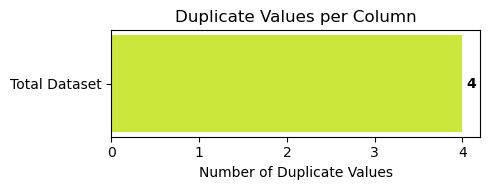

In [136]:
fig,ax = plt.subplots(figsize=(5,2))
ax.barh(duplicate.index,duplicate['Duplicate Count'].values,color="#cbe73c")
ax.set_xlabel("Number of Duplicate Values")
ax.set_title("Duplicate Values per Column")
for i,v in enumerate(duplicate['Duplicate Count'].values):
    if v > 0:
        ax.text(v+0.05,i,str(v),va='center',fontweight='bold')
plt.tight_layout()
plt.show()

## 4.Target Variabel Distribution

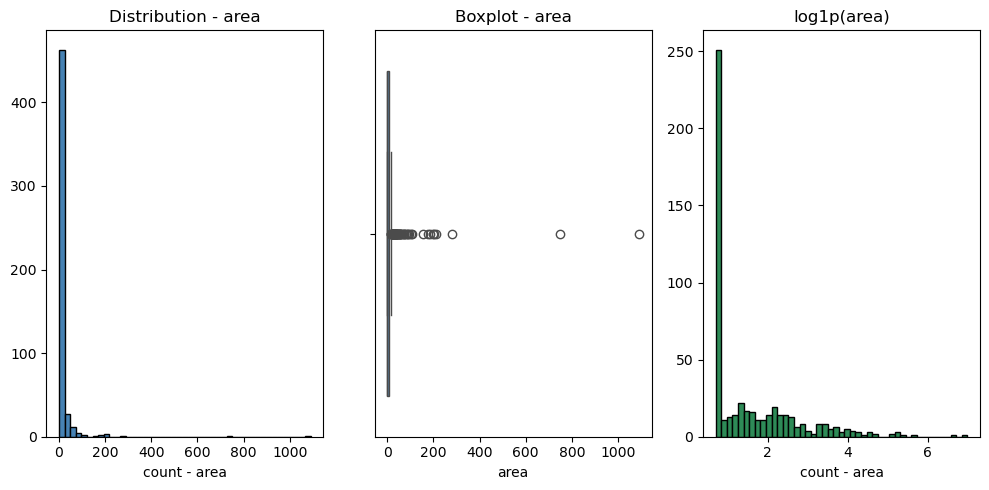

In [137]:
fig,axes = plt.subplots(1,3,figsize=(10,5))
axes[0].hist(df[y_target].dropna(),bins=45,color='steelblue',edgecolor='black')
axes[0].set_title(f'Distribution - {y_target}')
axes[0].set_xlabel(f'count - {y_target}')

sns.boxplot(x=df[y_target].dropna(),ax = axes[1],color='steelblue')
axes[1].set_title(f'Boxplot - {y_target}') 

axes[2].hist(np.log1p(df[y_target].dropna() + 1),bins=45,color='seagreen',edgecolor='black')
axes[2].set_title(f'log1p({y_target})')
axes[2].set_xlabel(f'count - {y_target}')
plt.tight_layout()
plt.show()

## 5. Univariat Analysis -- Numerical Features

In [138]:
feature_numerik = df.select_dtypes(include=[np.number]).columns.to_list()
ignored_features = [y_target]
feature_numerik = [col for col in feature_numerik if col not in ignored_features]

print(f'Numeric features ({len(feature_numerik)}):')
print(feature_numerik[:30])

Numeric features (10):
['X', 'Y', 'FFMC', 'DMC', 'DC', 'ISI', 'temp', 'RH', 'wind', 'rain']


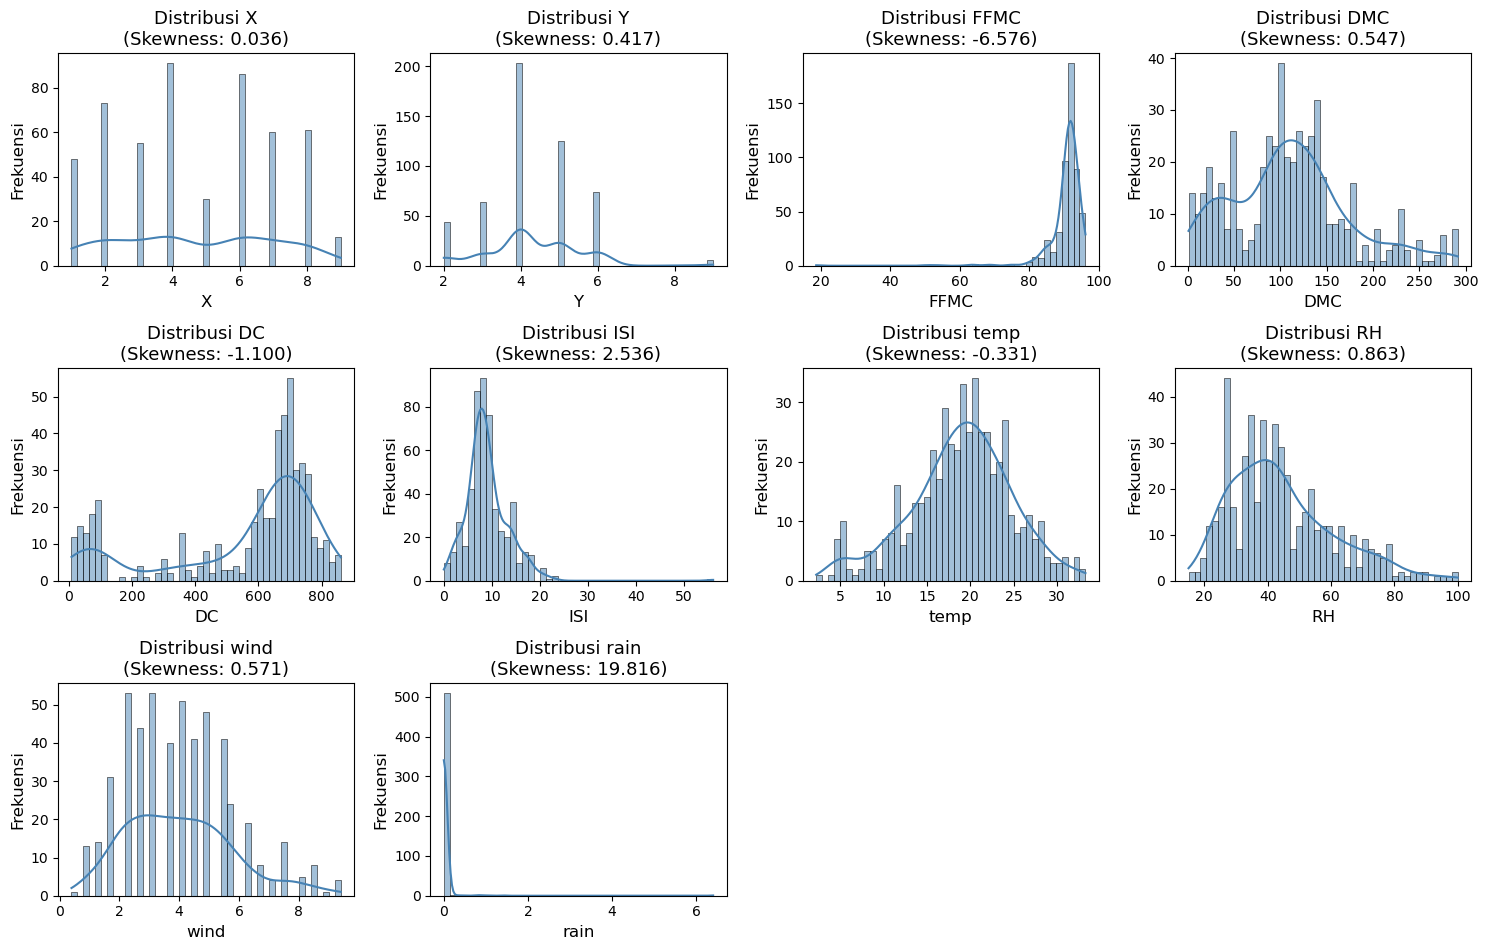

In [139]:
n_show = len(feature_numerik)
n_cols = 4
nrows = math.ceil(n_show/n_cols)

fig,axes = plt.subplots(nrows,n_cols,figsize=(15,3.2*nrows))
axes = axes.flatten()
for i,feature in enumerate(feature_numerik):
    feat_skew = df[feature].skew()
    sns.histplot(df[feature],ax=axes[i],kde=True,color='steelblue',edgecolor='black',bins=45)
    axes[i].set_title( f"Distribusi {feature}\n(Skewness: {feat_skew:.3f})",fontsize=13)
    axes[i].set_xlabel(feature, fontsize=12)
    axes[i].set_ylabel("Frekuensi", fontsize=12)
for j in range(n_show, len(axes)):
    axes[j].axis('off')
plt.tight_layout()
plt.show()

## 6. Univariate Analysis -- Categorical Features

In [140]:
feature_categori = df.select_dtypes(include='object').columns.to_list()
print(f'Numeric features ({len(feature_categori)}):')
print(feature_categori)

Numeric features (2):
['month', 'day']


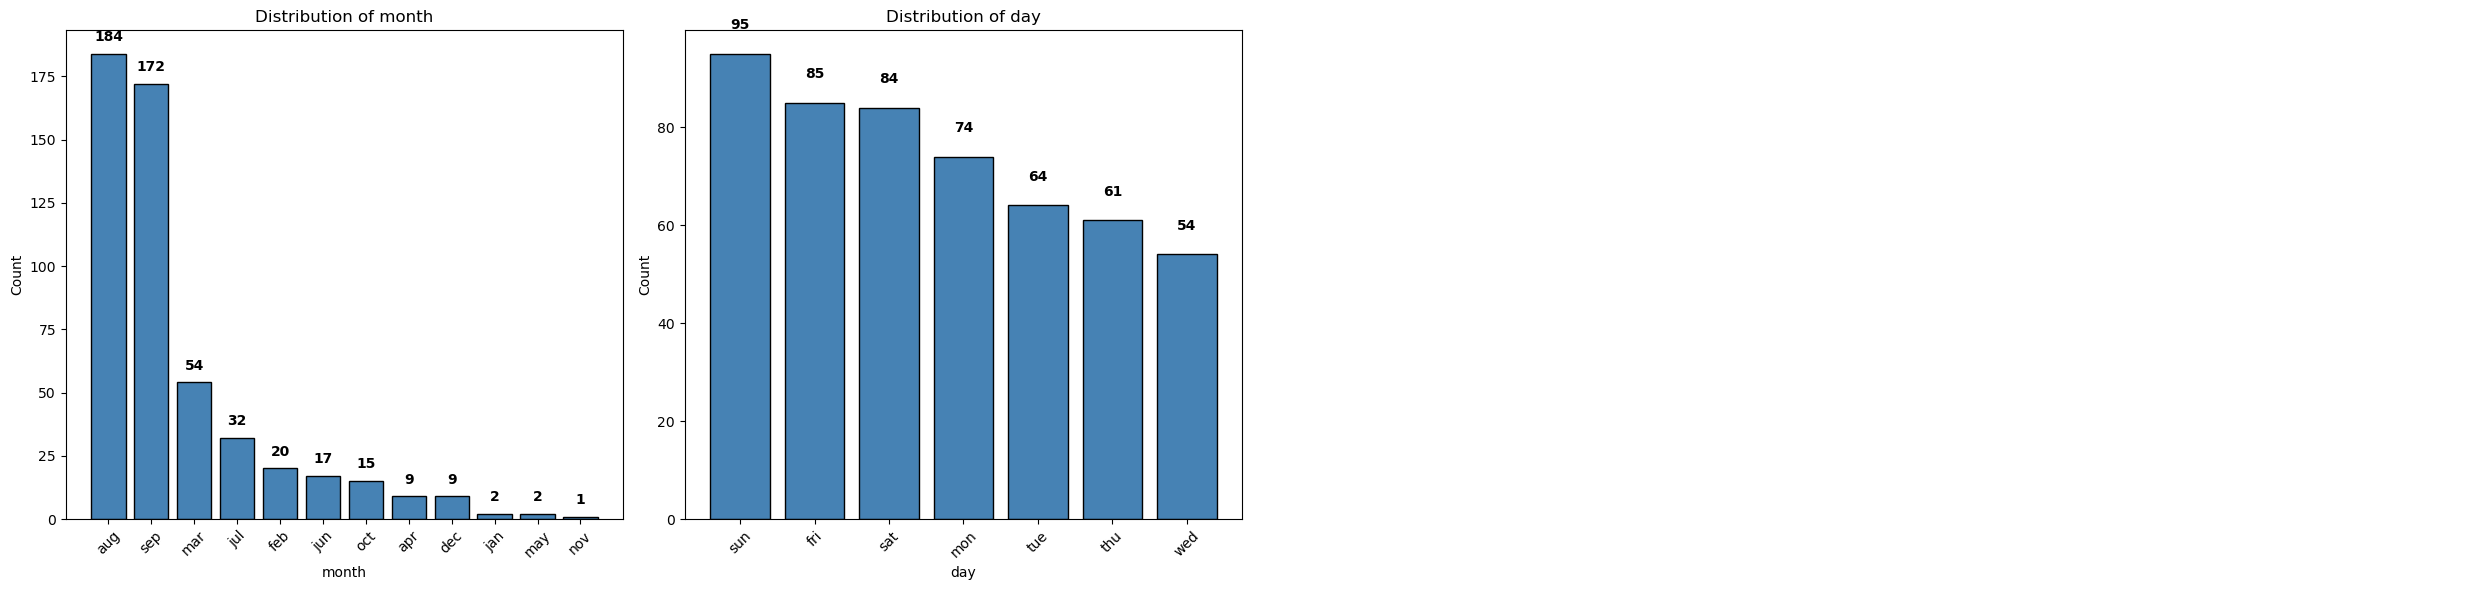

In [141]:
n_show = len(feature_categori)
n_cols = 4
nrows = math.ceil(n_show/n_cols)

fig,axes = plt.subplots(nrows,n_cols,figsize=(25,6*nrows))
axes = axes.flatten()
for i,feature in enumerate(feature_categori):
    counts = df[feature].value_counts()
    axes[i].bar(counts.index.astype(str), counts.values, color='steelblue', edgecolor="black")
    axes[i].set_title(f"Distribution of {feature}")
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel("Count")
    axes[i].tick_params(axis='x', rotation=45)
    for j, v in enumerate(counts.values):
        axes[i].text(j, v + 5, str(v), ha="center", fontweight="bold")
    for j in range(n_show, len(axes)):
        axes[j].axis('off')
plt.tight_layout()
plt.show()

## 7.Bivariate Analysis -- Features VS Target

In [142]:
feature_numerik = df.select_dtypes(include=[np.number]).columns.to_list()

df= df[df[y_target] != 0]

# for col in feature_numerik:
#     df[col] = np.sign(df[col]) * np.sqrt(np.abs(df[col]))

corrs_all = df[feature_numerik].corr()[y_target].abs().sort_values(ascending=False)
top_features = [x for x in corrs_all.index if x != y_target][:20]
print('Top features by |correlation| with target:')
print(corrs_all[top_features].round(3))

Top features by |correlation| with target:
temp    0.110
RH      0.105
DMC     0.089
X       0.070
FFMC    0.054
Y       0.050
DC      0.047
rain    0.013
ISI     0.002
wind    0.002
Name: area, dtype: float64


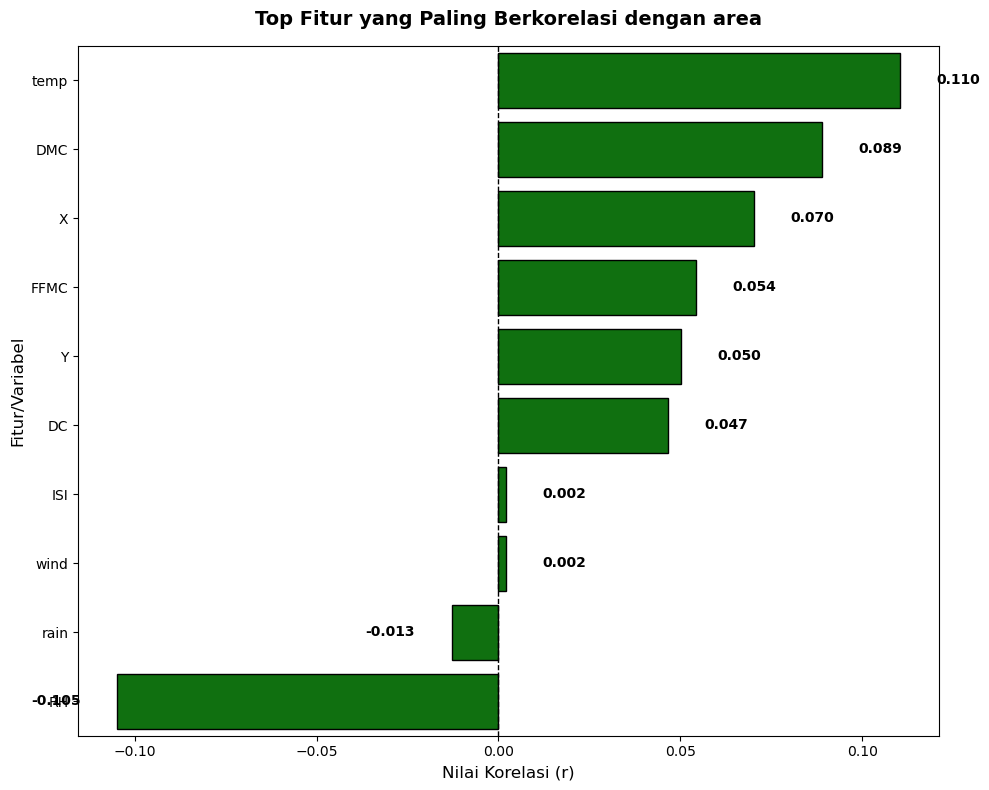

In [143]:
corrs_visual = df[feature_numerik].corr()[y_target][top_features].sort_values(ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(x=corrs_visual.values, y=corrs_visual.index, color='green', edgecolor='black')
plt.axvline(x=0, color='black', linestyle='--', linewidth=1)
for i, val in enumerate(corrs_visual.values):
    ha_pos = 'left' if val >= 0 else 'right'
    offset = 0.01 if val >= 0 else -0.01
    plt.text(val + offset, i, f'{val:.3f}', va='center', ha=ha_pos, fontsize=10, fontweight='bold')

plt.title(f'Top Fitur yang Paling Berkorelasi dengan {y_target}', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Nilai Korelasi (r)', fontsize=12)
plt.ylabel('Fitur/Variabel', fontsize=12)
plt.tight_layout()
plt.show()

In [144]:
df.head()

,X,Y,month,day,FFMC,DMC,DC,ISI,temp,RH,wind,rain,area
138,9,9,jul,tue,85.8,48.3,313.4,3.9,18.0,42,2.7,0.0,0.36
139,1,4,sep,tue,91.0,129.5,692.6,7.0,21.7,38,2.2,0.0,0.43
140,2,5,sep,mon,90.9,126.5,686.5,7.0,21.9,39,1.8,0.0,0.47
141,1,2,aug,wed,95.5,99.9,513.3,13.2,23.3,31,4.5,0.0,0.55
142,8,6,aug,fri,90.1,108.0,529.8,12.5,21.2,51,8.9,0.0,0.61


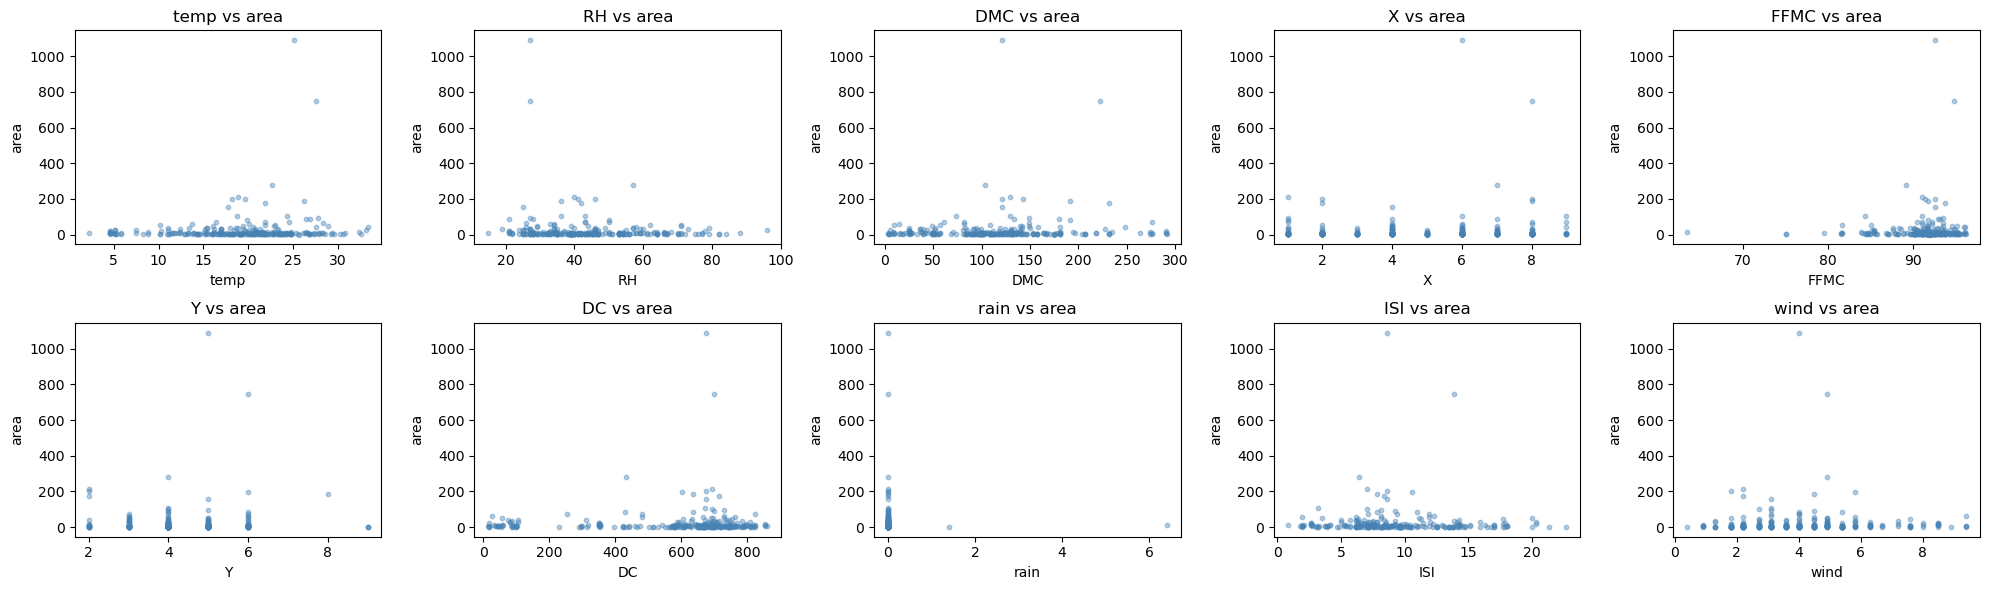

In [145]:
n_show = len(top_features)
n_cols = 5
nrows = math.ceil(n_show/n_cols)

fig,axes = plt.subplots(nrows,n_cols,figsize=(20,3.0*nrows))
axes = axes.flatten()
for i,feature in enumerate(top_features):
    axes[i].scatter(df[feature],df[y_target],alpha=0.4,s=10,color='steelblue')
    axes[i].set_xlabel(feature); axes[i].set_ylabel(f'{y_target}')
    axes[i].set_title(f'{feature} vs {y_target}')
for j in range(n_show, len(axes)):
    axes[j].axis('off')
plt.tight_layout()
plt.show()

## 8.Multivariat Analysis

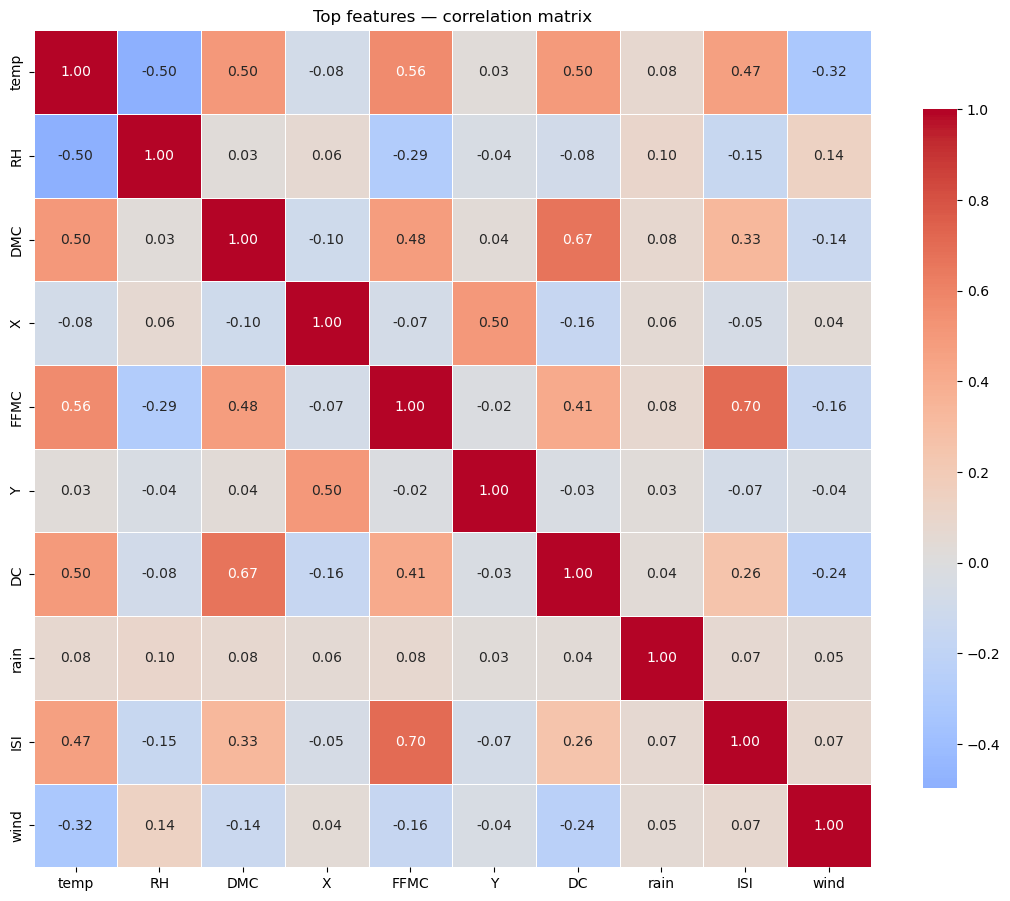

In [146]:
corr_matrix = df[top_features].corr()
plt.figure(figsize=(11,10))
sns.heatmap(corr_matrix,annot=True,fmt='.2f', cmap='coolwarm', center=0, square=True, linewidths=0.5, cbar_kws={'shrink': 0.7})
plt.title('Top features — correlation matrix')
plt.tight_layout()
plt.show()

## 9.Deep Analysis Feature 'day' & 'month'

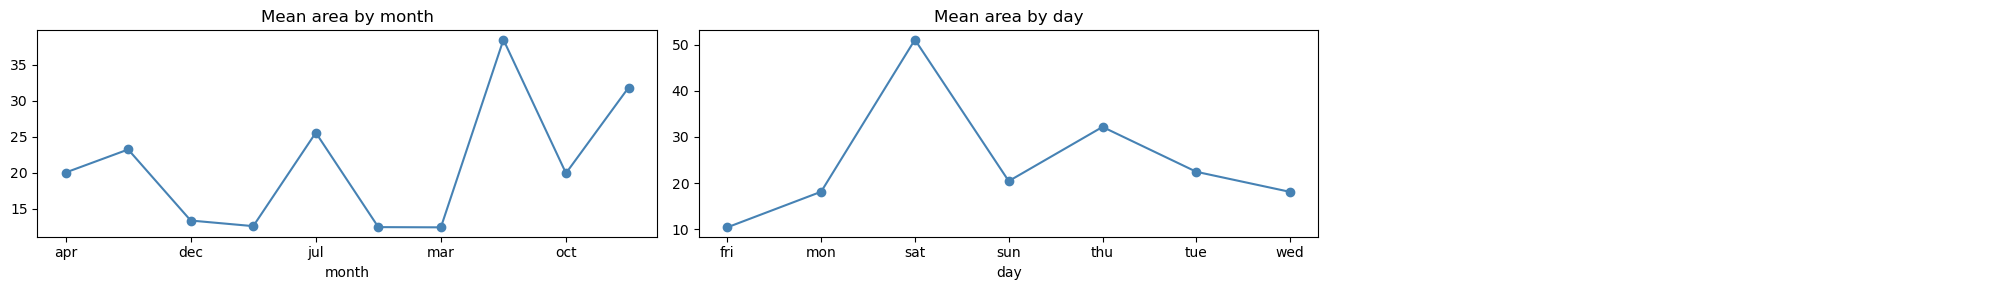

In [147]:
feature_year = ['month', 'day']
n_show = len(feature_year)
n_cols = 3
nrows = math.ceil(n_show/n_cols)

fig,axes = plt.subplots(nrows,n_cols,figsize=(20,3.0*nrows))
axes = axes.flatten()
for i,feature in enumerate(feature_year):
    df.groupby(feature)[y_target].mean().plot(ax=axes[i], marker='o', color='steelblue')
    axes[i].set_title(f'Mean {y_target} by {feature}')
for j in range(n_show, len(axes)):
    axes[j].axis('off')
plt.tight_layout()
plt.show()

## 10.Summary of Key Findings

In [148]:
summary = pd.DataFrame({
    'Metric': ['Total samples', 'Total features', 'Target mean', 'Target median',
               'Target stddev', 'Target min', 'Target max', 'Target skewness',
               'Top correlated feature', 'Top correlation value'],
    'Value': [
        len(df), df.shape[1] - 1,
        round(df[y_target].mean(), 2),
        round(df[y_target].median(), 2),
        round(df[y_target].std(), 2),
        round(df[y_target].min(), 2),
        round(df[y_target].max(), 2),
        round(df[y_target].skew(), 3),
        top_features[0],
        round(corrs_all[top_features[0]], 3),
    ],
})
summary

,Metric,Value
0,Total samples,270
1,Total features,12
2,Target mean,24.6
3,Target median,6.37
4,Target stddev,86.5
5,Target min,0.09
6,Target max,1090.84
7,Target skewness,9.445
8,Top correlated feature,temp
9,Top correlation value,0.11
